Contexte

Le défaut de paiement constitue un enjeu majeur pour les institutions financières. Lorsqu'une banque accorde une carte de crédit à un client, elle prend le risque que celui-ci ne rembourse pas les sommes empruntées. Une mauvaise évaluation de ce risque peut entraîner des pertes financières importantes. Il est donc essentiel de disposer d'outils capables d'identifier les clients susceptibles de faire défaut avant que celui-ci ne survienne.

Problématique

Dans ce projet, nous nous intéressons à la prédiction du défaut de paiement de clients détenteurs d'une carte de crédit. À partir d'informations démographiques, financières et comportementales, l'objectif est de déterminer si un client effectuera ou non un défaut de paiement le mois suivant.

Objectif

Ce problème est formulé comme une tâche de classification binaire supervisée. L'objectif est de comparer plusieurs modèles de machine learning afin d'identifier celui offrant les meilleures performances prédictives pour ce problème.

Pour ne pas avoir de problèmes lors des imports des fonctions dans les fichiers du dossier src

In [ ]:
%cd c:\Users\utcpret\Documents\GI04\AI28\Tps\Project

In [126]:
# WARNINGS
import warnings
warnings.filterwarnings('ignore')

# NUMPY
import numpy as np

# STATS
import scipy.stats as stats
from scipy.stats import norm, skew

# MATPLOTLIB
import matplotlib as mlp
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight') 

# PANDAS
import pandas as pd 
pd.set_option("display.max_rows", None, "display.max_columns", None) 

# SEABORN
import seaborn as sns

# SCIKIT-LEARN: SELECTION DE VARIABLES

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# SCIKIT-LEARN: PRE-PROCESSING
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder # Encodage des variables catégorielles ordinales
from sklearn.preprocessing import LabelBinarizer, OneHotEncoder # Encodage des variables catégorielles nominales
from sklearn.preprocessing import StandardScaler # Normalisation des variables numériques
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer # Imputation
from sklearn.impute import KNNImputer 

# SCIKIT-LEARN: MODELES
from sklearn.linear_model import LogisticRegression

# SCIKIT-LEARN: VALIDATION CROISEE + OPTIMISATION
from sklearn.model_selection import train_test_split # Séparer en données train et test
from sklearn.model_selection import cross_val_score # Validation croisée pour comparison entre modèles
from sklearn.model_selection import validation_curve # Courbe de validation : visulaisr des scores lors du choix d'un hyper-paramètre
from sklearn.model_selection import GridSearchCV # Tester plusieurs hyper-paramètres
from sklearn.model_selection import learning_curve # Courbe d'apprentissage : visualisation des scores du train et du validation sets en fonction des quanitiés des données
 
## EVALUATION
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score


# SCHIKIT-LEARN: PIPELINE AND TRANSFORMATEURll
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

# Fontions
from src.preprocessing import build_logistic_preprocessor,build_robust_preprocessor
from src.evaluation import train_and_evaluate, plot_confusion_matrix
from src.modeling import build_adaboost_model



Analyse Exploratoire de Données (AED)

In [ ]:
! pip install xlrd

In [ ]:
data = pd.read_excel('data/default of credit card clients.xls', header=1)
df = data.copy()

In [ ]:
df.head()

In [ ]:
df.tail()

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.columns.values

In [ ]:

# Résumé statistique des variables
print(df.dtypes)
df.describe()

Description des variables

- Limit_Bal : montant du crédit accordé, variable continue
- sex: 1 (homme), 2 (femme) => variable catégorielle
- Education : 1 = études supérieures ; 2 = études universitaires ; 3 = études secondaires ; 4 = autres => variable catégorielle
- Marriage : 1 = marié(e) ; 2 = célibataire ; 3 = autres => variable catégorielle
- Age : en années, variable continue 
- Pay_0 à Pay_6 : état du remboursement des paiements mensuels antérieurs ( de Septembre à Avril 2005) => : -1 = paiement à l’échéance ; 1 = retard de paiement d’un mois ; 2 = retard de paiement de deux mois. Variables continues
- Bill_Amt1 à Bill_Amt5 : montant de la facture en $ => variable continue
- Pay_Amt1 à Pay_Amt6 : montant du paiement précédent en $ => variable continue
- default payment next month : variable cible vaut 1(oui) et 0(non) => defaut de paiement, variable binaire discrète. 

In [ ]:
# Liste des colonnes d'historique de paiement
cols_pay = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Boucle pour afficher les pourcentages de chaque colonne
for col in cols_pay:
    print(f"\n--- Parts des modalités pour {col} (en %) ---")
    # multiplié par 100 pour avoir une lecture directe en pourcentage
    print((df[col].value_counts(normalize=True) * 100).round(2))
    nb_moins_deux = (df[cols_pay] == -2).sum()

print("Nombre d'occurrences de la modalité -2 :")
print(nb_moins_deux)

Description de la variable d'intérêt

In [ ]:
df['default payment next month'].describe()
df['default payment next month'].value_counts()
df['default payment next month'].value_counts(normalize=True)


On remarque que le dataset est très déséquilibré avec uniquement 22% des variables pour la classe 1 (défaut de paiement)

In [ ]:
target = df['default payment next month']
var_explicatives = df.drop('default payment next month',axis=1)

In [ ]:
# Vérifier l'existence des duplications d'exemples 
duplicate_df = df[df.duplicated()]
duplicate_df

In [ ]:
# Matrice de corrélation
corrmat = df.corr(numeric_only=True)
plt.figure(figsize=(30,30))
sns.heatmap(corrmat, cmap='coolwarm', square=True,annot = True)
plt.title("Matrice de corrélation")


### Interprétation
L'analyse montre une très forte corrélation (entre 0.80 et 0.95) entre les montants des factures (BILL_AMT1 à BILL_AMT6). Cela indique que les montants facturés sur des mois consécutifs évoluent de manière similaire et traduisent le niveau d'endettement du client. De plus ces variables Bill_AMT sont aussi corrélées avec les variables Pay_AMT car les clients bénéficiant d'une limite de crédit élevée réalisent souvent des dépenses plus importantes.

De même, les statuts de paiement (PAY_0 à PAY_6) sont fortement corrélés entre eux (entre 0.47 et 0.82), indiquant qu'un client en retard de paiement un mois donné a tendance à l'être aussi les mois qui suivent. Enfin, on observe une corrélation négative de -0.41 entre l'âge et le statut marital, confirmant logiquement que les clients plus âgés sont plus souvent mariés.

In [ ]:
plt.rcParams["figure.figsize"] = (8, 5)
corrmat['default payment next month'].sort_values(ascending=True)[:-1].plot(kind='barh')
plt.title("Corrélation entre les variables explicatives et la cible")
plt.tight_layout()
plt.show()

Les variables d'historique de paiement (PAY_0 à PAY_6) sont les plus prédictives, avec une corrélation positive qui s'accentue à mesure qu'on se rapproche de l'échéance, passant de 0.19 en avril (PAY_6) à 0.32 en septembre (PAY_0). 

À l'inverse, la limite de crédit (LIMIT_BAL) présente une corrélation négative de -0.15, ce qui montre que les clients ayant de gros crédits font statistiquement moins de défauts. Pour finir, les variables socio-démographiques comme le sexe, l'âge, l'éducation ou le mariage ont des corrélations proches de zéro, ce qui signifie qu'elles n'ont pas d'impact linéaire direct sur le risque de défaut.

Visualisation variables numériques vs cible

In [ ]:
var_numeric = ['PAY_AMT1','PAY_AMT6','LIMIT_BAL']
for col in var_numeric: 
    plt.figure(figsize=(6,4))
    sns.boxplot(x="default payment next month",y=col,data=df)
    plt.title(f"Distribution de {col} selon le défaut de paiement")

Les distributions de PAY_AMT1 et PAY_AMT6 affichent un comportement très similaire. Pour les deux classes (0 et 1), la grande majorité des paiements est concentrée près de zéro, ce qui rend les boîtes très écrasées. Cependant, on observe une présence beaucoup plus importante de valeurs aberrantes (les points individuels très hauts) chez les clients qui ne font pas défaut (classe 0). Cela indique que les clients qui effectuent de très gros paiements ponctuels basculent statistiquement beaucoup moins en défaut de paiement.

Le graphique montre que les clients qui ne font pas défaut (classe 0) ont globalement une limite de crédit plus élevée que ceux en défaut de paiement (classe 1). La boîte de la classe 0 est positionnée plus haut, avec une médiane proche de 150 000 NT$, tandis que celle de la classe 1 se situe en dessous de 100 000 NT$. Cela confirme l'existence d'une relation négative : les profils jugés plus risqués reçoivent des limites de crédit plus faibles de la part de la banque.

Visualisation variables catégorielles vs cible

In [ ]:
var_cat = ['SEX', 'EDUCATION', 'MARRIAGE']

for col in var_cat:
    plt.figure(figsize=(8, 5))
    # Le paramètre 'hue' permet de ventiler chaque catégorie selon la cible (0 ou 1)
    sns.countplot(x=col, hue='default payment next month', data=df, palette='Set2')
    plt.title(f"Répartition du défaut de paiement selon {col}")
    plt.ylabel("Nombre de clients")


Commentaire

L'analyse des proportions montre que le risque de défaut de paiement varie selon le profil des clients, même si les volumes globaux peuvent être trompeurs. On observe que les hommes (SEX = 1) présentent un taux de défaut légèrement plus élevé que les femmes, avec environ 25% de clients en échec contre 22%. Du côté de la situation matrimoniale, les personnes mariées (MARRIAGE = 1) affichent également une proportion de défaut légèrement supérieure à celle des célibataires. Enfin, concernant le niveau d'études (EDUCATION), ce sont les clients ayant un niveau d'études secondaires (catégorie 3) qui présentent la part de défaut de paiement la plus importante par rapport à leur effectif total.

Pré Traitement

In [ ]:
missing_data = df.isna()
sns.heatmap(missing_data,cbar=False)
# Pourcentage des valeurs manquantes
miss_rates = (missing_data.sum() /df.shape[0])*100
# Trie dans l'ordre croissant
miss_rates = miss_rates.sort_values(ascending=True)
print(miss_rates)

Comme souligné dans la description du problème, il n'y a aucune donnée manquante. 

In [ ]:
data_clean = df.drop('ID',axis=1)
data_clean.head(3)

Pour les variables PAY_0 à PAY_6, nous choisissons de les traiter comme des variables numériques ordonnées. Comme il y a une notion d'intensité dans le retard de paiement (plus le chiffre est grand, plus le retard est important), nous allons simplement les normaliser à l'aide d'un StandardScaler dans notre pipeline, à l'exception du cas où nous testerions une régression logistique, pour laquelle un OneHotEncoder pourrait être testé afin de mieux séparer les codes négatifs (-1, -2).

Nous avons commencé par un modèle de référence simple (régression logistique), avant d'explorer des modèles plus complexes et des stratégies de prétraitement plus avancées.

In [ ]:
X = data_clean.drop("default payment next month",  axis=1)

y = data_clean["default payment next month"]
# Vérification des dimensions du dtaframe
print(X.shape)
print(y.shape)
print(data_clean.shape)

Séparation des données en train et test sets

In [ ]:
# 70% train / 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 15% val / 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

Ré utilisation de la fonction de pré traitement pour passer à l'entrainement du modèle sur la régression logistique

In [ ]:
preprocessor = build_logistic_preprocessor()

Construction de la pipeline pour un modèle de régression logistique

In [ ]:
model = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000, random_state=42)
)

Entrainement et métriques du modèle

In [134]:
reg_log_simple = train_and_evaluate(model,X_train,y_train,X_test,y_test)

--------- Métriques pour TRAIN ---------
              precision    recall  f1-score   support

           0       0.82      0.97      0.89     18691
           1       0.72      0.25      0.37      5309

    accuracy                           0.81     24000
   macro avg       0.77      0.61      0.63     24000
weighted avg       0.80      0.81      0.77     24000

--------- Métriques pourTEST ---------
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



Matrice de confusion sur le train set

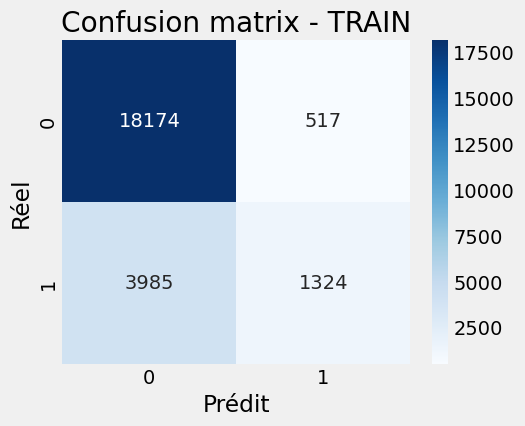

In [138]:
y_pred_train = model.predict(X_train)
cm_train = plot_confusion_matrix(y_train, y_pred_train, title="Confusion matrix - TRAIN")

Comparaison des résultats sur les ensembles de train et test

On remarque que le modèle a des performance similaires sur le train set et le test set. En effet, on observe une precision assez importante (0.82) pour la classe 0 (absence de défautd e paiement) aussi bien sur le train que sur le test set. Cependant, les recall sont assez faible sur la classe 1 (défaut de paiement) ce qui se traduit par une importante quantité de faux négatifs qui correspondent à des prédictions pour lesquelles les clients sont en défaut de paiement mais classés dans la classe 0. Donc notre but est d'améliorer ce modèle en vue d'augmenter le plus le recall qui est la métrique la plus importante pour la banque qui ne souhaite pas faire faillite.

Voyons voir si on ajoute le paramètre balanced

In [ ]:
model_2 = make_pipeline(
    preprocessor,
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
)

In [139]:
reg_log_balanced = train_and_evaluate(model_2,X_train,y_train,X_test,y_test)

--------- Métriques pour TRAIN ---------
              precision    recall  f1-score   support

           0       0.88      0.70      0.78     18691
           1       0.38      0.65      0.48      5309

    accuracy                           0.69     24000
   macro avg       0.63      0.68      0.63     24000
weighted avg       0.77      0.69      0.71     24000

--------- Métriques pourTEST ---------
              precision    recall  f1-score   support

           0       0.87      0.69      0.77      4673
           1       0.37      0.63      0.47      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000



Matrice de confusion sur le test set

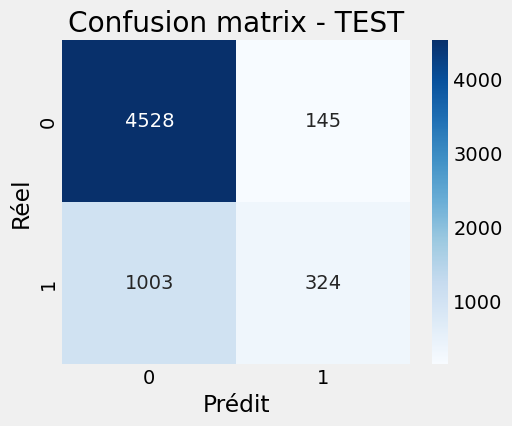

In [132]:
y_pred_test = model.predict(X_test)
cm_test = plot_confusion_matrix(y_test, y_pred_test, title="Confusion matrix - TEST")


L’utilisation du paramètre class_weight="balanced" améliore significativement la détection des clients en défaut de paiement, avec une augmentation du recall de la classe 1. Toutefois, cette amélioration s’accompagne d’une baisse de la précision, entraînant davantage de faux positifs.

Dans ce contexte, le F1-score constitue une métrique pertinente car il permet de trouver un compromis entre précision et rappel. L’objectif est donc d’optimiser ce compromis tout en tenant compte des coûts métier associés aux erreurs de classification.

RESULTATS BONS DANS LA GESTION DE RISQUE : contexte métier ici

L'activation du mode class_weight='balanced' illustre parfaitement le compromis entre Précision et Recall. Bien que la précision pour la classe 1 diminue légèrement à 37 % (entraînant davantage de fausses alertes), le Recall augmente de façon spectaculaire pour atteindre 64 % sur le jeu de test. >
D'un point de vue métier, ce modèle est largement préférable car il permet de détecter la majorité des clients en défaut de paiement. Cette amélioration globale est confirmée par le F1-score de la classe 1, qui progresse nettement en passant de 0.35 à 0.47.

Le seuil de classification par défaut (0.5) n’est pas adapté au déséquilibre des classes. Nous optimisons donc ce seuil sur le jeu de validation afin de maximiser la métrique F1-score (ou recall selon l’objectif métier), permettant un meilleur compromis entre détection des défauts et limitation des faux positifs.

In [ ]:
y_val_proba = model.predict_proba(X_val)[:, 1]

In [ ]:

thresholds = np.linspace(0.1, 0.9, 81)

best_threshold = 0.5
best_score = 0

for t in thresholds:
    y_pred = (y_val_proba >= t).astype(int)

    score = f1_score(y_val, y_pred)  # ou recall_score selon objectif

    if score > best_score:
        best_score = score
        best_threshold = t

print("Meilleur seuil :", best_threshold)
print("Meilleur score val :", best_score)

Le seuil optimal de classification n’est pas 0.5 mais 0.28, ce qui confirme le déséquilibre des classes. L’abaissement du seuil permet d’augmenter la détection des défauts de paiement, au prix d’une hausse des faux positifs. Le compromis retenu maximise le F1-score sur le jeu de validation.

In [ ]:
y_test_proba =  model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc_score = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # baseline aléatoire

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

L'obtention d'une AUC de 0.718 montre que le modèle parvient à prédire de manière correcte les clients à risque de ceux solvables.

Dans la suite nous allons tester, entrainer d'autres modèles histoire de comparer les performances de chacun pour choisir le meilleur susceptible d'estimer avec précision la probabilité réelle de défaut.

Avant on va essayer un autre pré traitement avec RobustScaler pour traiter les variables catégorielles plutôt que StandarScaler

In [ ]:
preprocessor_robust = build_robust_preprocessor()

In [ ]:
model_robust = make_pipeline(preprocessor_robust,LogisticRegression(max_iter=1000, random_state=42))

In [ ]:
reg_logrobust =  train_and_evaluate(model_robust,X_train,y_train,X_test,y_test)

Les rapports de classification montrent que le modèle ne sur-apprenp pas (overfitting), car les performances sur le jeu de test (Accuracy de 0.81, F1-score de 0.35) restent très proches de celles du jeu d'entraînement. Cependant, le modèle peine fortement à prédire la classe minoritaire (1) avec un recall très faible de 24 %.

De plus, l'utilisation du RobustScaler à la place du StandardScaler fournit des métriques strictement identiques. Cela indique que le jeu de données ne contient pas de valeurs aberrantes extrêmes capables d'influencer négativement le comportement de la régression logistique.

## Modélisation : AdaBoost

AdaBoost est une méthode d'ensemble **séquentielle (boosting)** : on entraîne plusieurs modèles faibles (des arbres de décision très courts) les uns après les autres, chacun se concentrant sur les observations mal classées par son prédécesseur. La prédiction finale est un vote pondéré de tous les arbres.

Contrairement à la régression logistique, les arbres n'ont pas besoin de normalisation : on réutilise donc `build_tree_preprocessor()` (encodage des variables catégorielles uniquement, le reste en passthrough).

In [127]:
'''import os, sys

# Le package src/ est à la racine du projet. Il faut le rendre importable, que le
# kernel tourne en local (notebook lancé depuis notebook/) ou sur Google Colab
# (machine distante qui n'a pas les fichiers du projet).
try:
    import google.colab          # ce module n'existe que sur Colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not os.path.isdir('src'):
    # Sur Colab : on clone la branche de travail pour récupérer le dossier src/
    if not os.path.isdir('Projet-AI28'):
        os.system('git clone -q -b Armand-branch-preprocessing '
                  'https://github.com/NdeyeAminataAida/Projet-AI28.git')
    sys.path.insert(0, os.path.abspath('Projet-AI28'))

# En local : ajoute la racine du projet au sys.path (parent de notebook/)
_cwd = os.getcwd()
PROJECT_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebook' else _cwd
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
'''

# Séparation variables explicatives / cible (on travaille sur data_clean, sans l'ID)
X = data_clean.drop('default payment next month', axis=1)
y = data_clean['default payment next month']

# Séparation train / test
# stratify=y conserve la proportion de défauts (~22%) dans les deux échantillons
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [128]:
# Construction du modèle AdaBoost (100 arbres faibles) et évaluation
# train_and_evaluate entraîne le modèle puis affiche le classification_report sur train et test
ada_model = build_adaboost_model(n_estimators=100)
ada_model = train_and_evaluate(ada_model, X_train, y_train, X_test, y_test)

--------- Métriques pour TRAIN ---------
              precision    recall  f1-score   support

           0       0.84      0.96      0.89     18691
           1       0.69      0.34      0.45      5309

    accuracy                           0.82     24000
   macro avg       0.76      0.65      0.67     24000
weighted avg       0.80      0.82      0.80     24000

--------- Métriques pourTEST ---------
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      4673
           1       0.67      0.33      0.44      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000



### Matrice de confusion (modèle de base)

Le `classification_report` donne les scores chiffrés ; la matrice de confusion permet de visualiser directement les erreurs : faux positifs (clients sans défaut prédits en défaut) et surtout faux négatifs (défauts non détectés), qui sont les plus coûteux pour la banque.

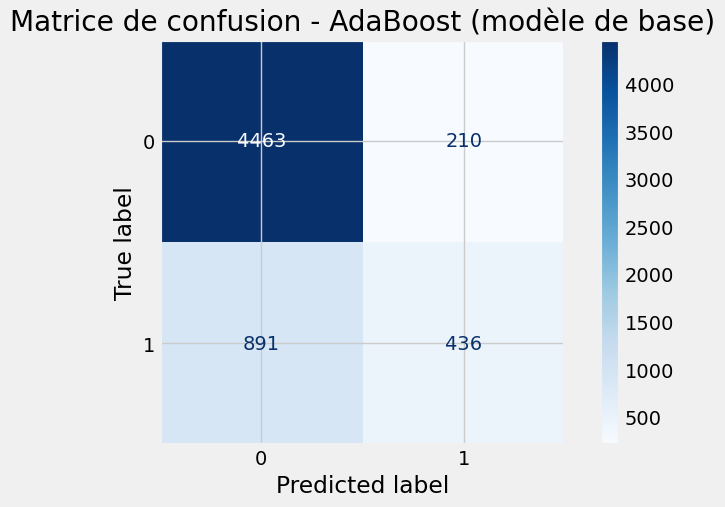

In [129]:
# Matrice de confusion sur le test set (ConfusionMatrixDisplay déjà importé plus haut)
ConfusionMatrixDisplay.from_estimator(ada_model, X_test, y_test, cmap='Blues')
plt.title("Matrice de confusion - AdaBoost (modèle de base)")
plt.show()

### Gestion du déséquilibre des classes

Le modèle de base atteint une bonne accuracy (~0.82) mais un **recall faible sur la classe "défaut" (~0.33)** : il rate les deux tiers des clients qui font réellement défaut, car la classe minoritaire (~22%) pèse peu dans l'apprentissage.

Pour corriger cela, on relance AdaBoost avec `class_weight='balanced'` sur l'arbre faible : les classes sont pondérées à l'inverse de leur fréquence, ce qui force le modèle à prêter plus d'attention aux défauts. On observe alors un **meilleur recall sur la classe 1**, au prix d'une précision et d'une accuracy globale plus faibles (compromis precision/recall).

--------- Métriques pour TRAIN ---------
              precision    recall  f1-score   support

           0       0.86      0.85      0.86     18691
           1       0.50      0.52      0.51      5309

    accuracy                           0.78     24000
   macro avg       0.68      0.69      0.69     24000
weighted avg       0.78      0.78      0.78     24000

--------- Métriques pourTEST ---------
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      4673
           1       0.50      0.50      0.50      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.68      0.68      6000
weighted avg       0.78      0.78      0.78      6000



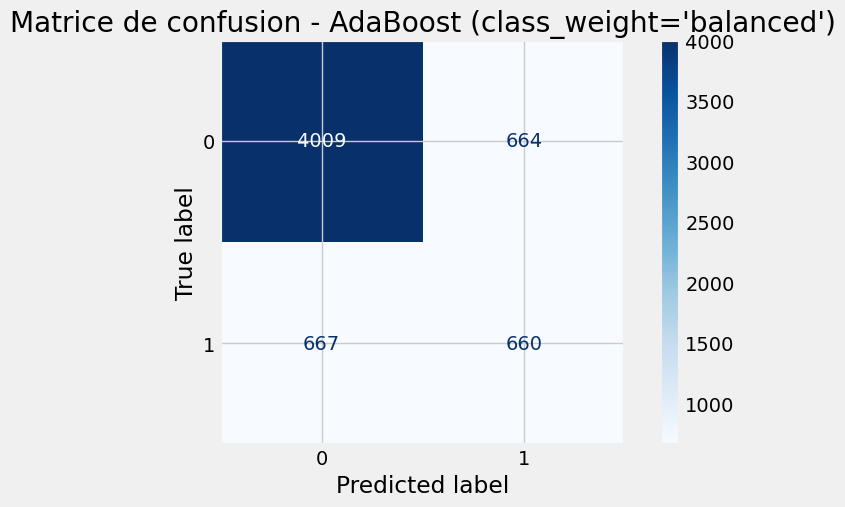

In [131]:
# AdaBoost avec pondération des classes pour traiter le déséquilibre
ada_balanced = build_adaboost_model(n_estimators=100, class_weight='balanced')
ada_balanced = train_and_evaluate(ada_balanced, X_train, y_train, X_test, y_test)

# Matrice de confusion du modèle pondéré (à comparer avec celle du modèle de base)
ConfusionMatrixDisplay.from_estimator(ada_balanced, X_test, y_test, cmap='Blues')
plt.title("Matrice de confusion - AdaBoost (class_weight='balanced')")
plt.show()

### Comparaison et bilan des performances (AdaBoost vs Régression Logistique)

L'introduction d'AdaBoost avec le paramètre class_weight='balanced' montre un comportement attendu : le modèle parvient à doubler son taux de détection des clients en défaut (le rappel de la classe 1 passe de 0,24 à 0,50). Toutefois, cette amélioration ne répond que partiellement aux exigences métiers de l'établissement financier. En effet, cette sensibilité accrue s'obtient au prix d'une dégradation majeure de la précision de la classe 1, qui chute à 0,50. Concrètement, cela signifie qu'une prédiction de défaut sur deux commise par le modèle est erronée, ce qui risquerait de pénaliser l'activité commerciale en refusant inutilement des clients solvables.

Face à ce déséquilibre de classes marqué (~22 % de défauts), l'analyse des métriques à un seuil de décision par défaut (0,5) montre ses limites. Pour trouver le meilleur compromis possible et maximiser simultanément la précision et le rappel, il est indispensable de faire varier ce seuil et d'analyser globalement la courbe Précision-Rappel (PRC).

L'évaluation de l'aire sous cette courbe (AUC-PRC) et de la précision moyenne (Average Precision) nous fournira un indicateur unique et robuste. Plus cette aire sera proche de 1, plus le modèle sera capable de cibler efficacement les défauts de paiement tout en limitant les faux positifs, offrant ainsi une solution réellement viable pour la gestion des risques de la banque.